In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from typing import Dict , TypedDict
from langgraph.graph import StateGraph

In [3]:
# AgentState - shared DS -keeps track of info 
class AgentState(TypedDict): #state schema
    name :str
    message : str 
    compliment : str

def greeting_node(state: AgentState) -> AgentState : #takes input as state , and returns updated state
    """ Simple node that adds a greeting msg to the state""" #-> DocStrings tells Agents what that function does
    
    state['message'] = state['name'] + ","

    return state

def compliment_node(state: AgentState) -> AgentState :
    """simple node that adds a compliment msg to the state"""
    state['compliment'] = state['message'] +" you are going an amazing job learning LangChain"
    return state
    

In [4]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node) #nameOfNode , action
graph.add_node("complimenter",compliment_node)

graph.set_entry_point("greeter")
graph.add_edge("greeter","complimenter")
graph.set_finish_point("complimenter")

app = graph.compile()

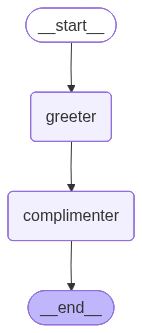

In [5]:
from IPython.display import Image , display
graph = app.get_graph()
png_bytes = graph.draw_mermaid_png()
display(Image(png_bytes))

In [6]:
result = app.invoke({"name":"Bob"})

In [7]:
result 


{'name': 'Bob',
 'message': 'Bob,',
 'compliment': 'Bob, you are going an amazing job learning LangChain'}